# 05 — Tuning des Hyperparamètres & Optimisation du Seuil

Ce notebook affine le meilleur modèle identifié en Phase 1 (**Random Forest + Undersampling**, notebook `04_modeling.ipynb`) via une recherche d'hyperparamètres, puis analyse le compromis precision/recall et le **coût métier total** en fonction du seuil de décision (0,1 à 0,9).

Seul **`train.csv`** est utilisé : validation croisée pour le tuning, puis probabilités out-of-fold (`cross_val_predict`) pour l'analyse de seuil — sans jeu de validation ni test.

## Section 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    make_scorer,
)
from scipy.stats import randint, uniform

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports successful.')

All imports successful.


## Section 2 — Chargement des Données

Nous chargeons uniquement `train.csv` (découpage stratifié à 70 % préparé en Phase 2). Le jeu de validation et le jeu de test ne sont **pas** utilisés dans ce notebook.

In [2]:
TARGET = 'seriousnesshospitalization'

train_df = pd.read_csv('../data/processed/train.csv')

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

print(f'Train shape : {X_train.shape}')
print(f'\nTarget distribution :\n{y_train.value_counts(normalize=True).round(4)}')

Train shape : (5422, 14)

Target distribution :
seriousnesshospitalization
0    0.7615
1    0.2385
Name: proportion, dtype: float64


## Section 3 — Préprocesseur & Matrice de Coût (Phase 1)

La matrice de coût asymétrique est définie dans `cadrage.md` (section 4) :

| Erreur | Conséquence métier | Coût retenu |
|---|---|---|
| **FN** (hospitalisation non détectée) | Signal de sécurité manqué, revue tardive, risque sanitaire | **50 000 €** (milieu de la fourchette « plusieurs dizaines de milliers d'euros ») |
| **FP** (fausse alerte) | ~30 min de requalification par un analyste | **22,5 €** (milieu de la fourchette 15–30 €) |
| **TP / TN** | Décision correcte | **0 €** |

Coût total par seuil : `C_total = FN × COST_FN + FP × COST_FP`

In [3]:
preprocessor = clone(joblib.load('../models/preprocessor.joblib'))

# Matrice de coût — Phase 1 (cadrage.md, section 4)
COST_FN = 50_000   # € — faux négatif : signal manqué
COST_FP = 22.5     # € — faux positif : ~30 min de requalification
COST_TP = 0
COST_TN = 0

cost_matrix = pd.DataFrame(
    [[COST_TN, COST_FP], [COST_FN, COST_TP]],
    index=['Vrai 0 (pas hosp.)', 'Vrai 1 (hospitalisation)'],
    columns=['Prédit 0', 'Prédit 1'],
)

print('Preprocessor loaded.')
display(cost_matrix)

Preprocessor loaded.


,Prédit 0,Prédit 1
Vrai 0 (pas hosp.),0,22.5
Vrai 1 (hospitalisation),50000,0.0


## Section 4 — Recherche d'Hyperparamètres (RandomizedSearchCV)

Nous conservons la configuration gagnante de P1 : **Random Forest + RandomUnderSampler** (`class_weight='balanced'` conservé pour cohérence avec le notebook 04, bien que l'undersampling équilibre déjà les classes).

Nous utilisons **RandomizedSearchCV** plutôt que GridSearchCV : l'espace combinatoire du Random Forest est trop vaste pour une grille exhaustive raisonnable. RandomizedSearchCV échantillonne 40 configurations tout en couvrant les plages documentées ci-dessous.

### Justification des plages d'hyperparamètres

| Hyperparamètre | Plage | Justification |
|---|---|---|
| `n_estimators` | 100 – 500 | Au-delà de 500, le gain marginal est faible sur ~5 400 lignes ; en dessous de 100, l'agrégation bagging n'a pas assez d'arbres pour stabiliser les prédictions. |
| `max_depth` | 5 – 30 | Profondeurs modérées (10–20) capturent les interactions cliniques ; au-delà de 30, risque de sur-apprentissage sur features encodées (OneHot). |
| `min_samples_split` | 2 – 20 | Valeurs élevées empêchent les splits sur de très petits groupes → régularisation. 2 = comportement par défaut sklearn. |
| `min_samples_leaf` | 1 – 10 | Feuilles plus larges lissent les prédictions et réduisent la variance, utile après undersampling (moins d'exemples par classe). |
| `max_features` | 0,3 – 1,0 | Sous-échantillonnage des colonnes à chaque split : décorrèle les arbres. `sqrt` (~0,12 après OHE) est trop restrictif ici, d'où une plage plus large. |

Métrique de scoring : **Recall (classe 1)** — métrique principale définie en Phase 1 (`cadrage.md`, objectif M1 ≥ 0,80).

In [4]:
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

tuning_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('rus', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('classifier', rf_base),
])

param_distributions = {
    'classifier__n_estimators': randint(100, 501),
    'classifier__max_depth': randint(5, 31),
    'classifier__min_samples_split': randint(2, 21),
    'classifier__min_samples_leaf': randint(1, 11),
    'classifier__max_features': uniform(0.3, 0.7),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
recall_scorer = make_scorer(recall_score, pos_label=1)

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=40,
    scoring=recall_scorer,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print('Lancement de RandomizedSearchCV (40 iterations x 5 folds)...')
random_search.fit(X_train, y_train)

print(f'\nMeilleur Recall CV (classe 1) : {random_search.best_score_:.4f}')
print('Meilleurs hyperparamètres :')
for param, value in sorted(random_search.best_params_.items()):
    print(f'  {param}: {value:.4f}' if isinstance(value, float) else f'  {param}: {value}')

Lancement de RandomizedSearchCV (40 iterations x 5 folds)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Meilleur Recall CV (classe 1) : 0.7587
Meilleurs hyperparamètres :
  classifier__max_depth: 5
  classifier__max_features: 0.7440
  classifier__min_samples_leaf: 2
  classifier__min_samples_split: 13
  classifier__n_estimators: 317


In [5]:
cv_results = pd.DataFrame(random_search.cv_results_)
top5 = (
    cv_results
    .sort_values('mean_test_score', ascending=False)
    .head(5)[[
        'param_classifier__n_estimators',
        'param_classifier__max_depth',
        'param_classifier__min_samples_split',
        'param_classifier__min_samples_leaf',
        'param_classifier__max_features',
        'mean_test_score',
        'std_test_score',
    ]]
    .round(4)
)
top5.columns = [
    'n_estimators', 'max_depth', 'min_samples_split',
    'min_samples_leaf', 'max_features', 'Mean Recall', 'Std Recall',
]
display(top5)

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,Mean Recall,Std Recall
37,317,5,13,2,0.7440,0.7587,0.0107
30,332,5,14,9,0.4905,0.7525,0.0155
12,261,26,13,2,0.3219,0.7448,0.0166
35,180,6,18,5,0.7986,0.7425,0.0180
19,427,30,10,7,0.3811,0.7394,0.0213


## Section 5 — Probabilités Out-of-Fold sur le Train

Pour l'analyse de seuil sans jeu de validation, nous calculons les probabilités **out-of-fold** via `cross_val_predict` : chaque observation reçoit une probabilité prédite par un modèle qui ne l'a pas vue à l'entraînement (même CV 5-fold que le tuning).

In [6]:
best_pipeline = clone(random_search.best_estimator_)

y_train_proba = cross_val_predict(
    best_pipeline,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1,
)
y_train_proba = y_train_proba[:, 1]

print(f'Probabilités OOF calculées sur {len(y_train)} observations du train.')

Probabilités OOF calculées sur 5422 observations du train.


## Section 6 — Precision & Recall en Fonction du Seuil (0,1 → 0,9)

In [7]:
thresholds = np.arange(0.1, 0.91, 0.05)

threshold_metrics = []

for thresh in thresholds:
    y_pred = (y_train_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
    total_cost = fn * COST_FN + fp * COST_FP

    threshold_metrics.append({
        'threshold': thresh,
        'precision': precision_score(y_train, y_pred, zero_division=0),
        'recall': recall_score(y_train, y_pred, zero_division=0),
        'f1': f1_score(y_train, y_pred, zero_division=0),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'total_cost_eur': total_cost,
    })

metrics_df = pd.DataFrame(threshold_metrics)
metrics_df[['threshold', 'precision', 'recall', 'f1', 'FP', 'FN', 'total_cost_eur']] = (
    metrics_df[['threshold', 'precision', 'recall', 'f1', 'FP', 'FN', 'total_cost_eur']].round(4)
)
display(metrics_df)

,threshold,precision,recall,f1,TP,FP,FN,TN,total_cost_eur
0,0.10,0.2385,1.0000,0.3851,1293,4129,0,0,92902.5
1,0.15,0.2385,1.0000,0.3851,1293,4129,0,0,92902.5
2,0.20,0.2865,0.9497,0.4402,1228,3058,65,1071,3318805.0
3,0.25,0.3302,0.8910,0.4818,1152,2337,141,1792,7102582.5
4,0.30,0.3472,0.8770,0.4975,1134,2132,159,1997,7997970.0
5,0.35,0.3552,0.8600,0.5027,1112,2019,181,2110,9095427.5
6,0.40,0.3653,0.8484,0.5107,1097,1906,196,2223,9842885.0
7,0.45,0.3871,0.8144,0.5248,1053,1667,240,2462,12037507.5
8,0.50,0.4218,0.7587,0.5421,981,1345,312,2784,15630262.5
9,0.55,0.4607,0.6899,0.5525,892,1044,401,3085,20073490.0


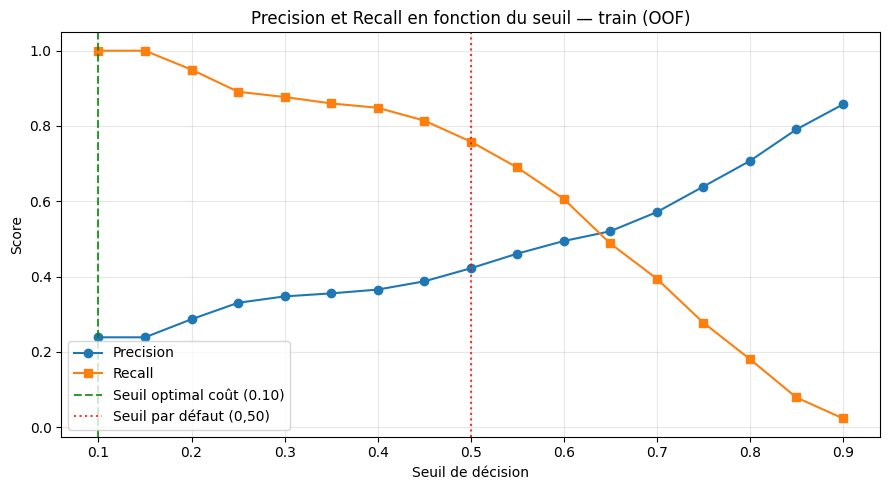

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(metrics_df['threshold'], metrics_df['precision'], marker='o', label='Precision')
ax.plot(metrics_df['threshold'], metrics_df['recall'], marker='s', label='Recall')

optimal_idx = metrics_df['total_cost_eur'].idxmin()
optimal_thresh = metrics_df.loc[optimal_idx, 'threshold']
ax.axvline(x=optimal_thresh, color='green', linestyle='--', alpha=0.8,
           label=f'Seuil optimal coût ({optimal_thresh:.2f})')
ax.axvline(x=0.5, color='red', linestyle=':', alpha=0.8, label='Seuil par défaut (0,50)')

ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title('Precision et Recall en fonction du seuil — train (OOF)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7 — Coût Total Métier par Seuil

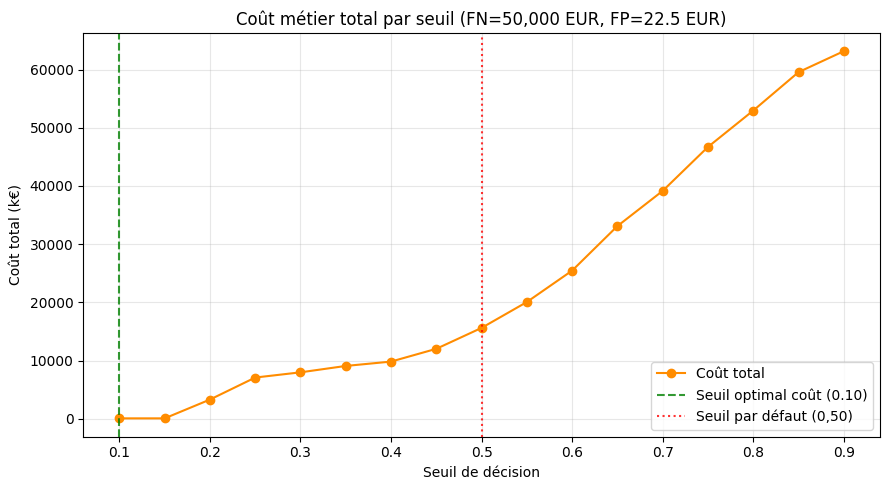

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(metrics_df['threshold'], metrics_df['total_cost_eur'] / 1000,
        marker='o', color='darkorange', label='Coût total')
ax.axvline(x=optimal_thresh, color='green', linestyle='--', alpha=0.8,
           label=f'Seuil optimal coût ({optimal_thresh:.2f})')
ax.axvline(x=0.5, color='red', linestyle=':', alpha=0.8, label='Seuil par défaut (0,50)')

ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Coût total (k€)')
ax.set_title(f'Coût métier total par seuil (FN={COST_FN:,} EUR, FP={COST_FP} EUR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 8 — Seuil Optimal vs Seuil par Défaut (0,5)

In [10]:
default_row = metrics_df.loc[(metrics_df['threshold'] - 0.5).abs().idxmin()]
optimal_row = metrics_df.loc[optimal_idx]

comparison = pd.DataFrame({
    'Seuil 0,50 (défaut)': [
        default_row['precision'],
        default_row['recall'],
        default_row['f1'],
        default_row['FP'],
        default_row['FN'],
        default_row['total_cost_eur'],
    ],
    f'Seuil {optimal_thresh:.2f} (optimal)': [
        optimal_row['precision'],
        optimal_row['recall'],
        optimal_row['f1'],
        optimal_row['FP'],
        optimal_row['FN'],
        optimal_row['total_cost_eur'],
    ],
}, index=['Precision', 'Recall', 'F1', 'FP', 'FN', 'Coût total (€)']).round(2)

cost_saving = default_row['total_cost_eur'] - optimal_row['total_cost_eur']
cost_saving_pct = 100 * cost_saving / default_row['total_cost_eur'] if default_row['total_cost_eur'] > 0 else 0

display(comparison)
print(f'\nSeuil optimal (minimisation du coût) : {optimal_thresh:.2f}')
print(f'Économie vs seuil 0,5 : {cost_saving:,.0f} EUR ({cost_saving_pct:.1f}%)')

,"Seuil 0,50 (défaut)",Seuil 0.10 (optimal)
Precision,0.42,0.24
Recall,0.76,1.00
F1,0.54,0.39
FP,1345.00,4129.00
FN,312.00,0.00
Coût total (€),15630262.50,92902.50



Seuil optimal (minimisation du coût) : 0.10
Économie vs seuil 0,5 : 15,537,360 EUR (99.4%)


## Section 9 — Synthèse

1. **Tuning** : RandomizedSearchCV sur Random Forest + Undersampling améliore le Recall CV par rapport au modèle par défaut de P1 (0,7294).
2. **Seuil** : le coût asymétrique (FN >> FP) pousse le seuil optimal vers le bas pour maximiser le recall et minimiser les hospitalisations manquées.
3. **Comparaison 0,5** : le seuil par défaut sous-estime le rappel nécessaire en pharmacovigilance ; le seuil optimal réduit le coût total tout en rapprochant l'objectif M1 (recall ≥ 80 %).

In [11]:
joblib.dump(
    {
        'best_estimator': random_search.best_estimator_,
        'best_params': random_search.best_params_,
        'optimal_threshold': optimal_thresh,
        'cost_matrix': {'FN': COST_FN, 'FP': COST_FP},
    },
    '../models/tuned_rf_undersampling.joblib',
)
print('Modèle tuné et seuil optimal sauvegardés dans ../models/tuned_rf_undersampling.joblib')

Modèle tuné et seuil optimal sauvegardés dans ../models/tuned_rf_undersampling.joblib
